# Logistic Regression - Multinomial Classification

In [28]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import livelossplot

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Importing Dataset

In [29]:
data = load_wine()
display(data)

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [30]:
X = data.data[:, :2]
y = data.target

print(f"Dataset shape = X={X.shape}, y={y.shape}")
print(f"Classes = {np.unique(y)}")
print(f"Feature names = {data.feature_names[:2]}")

Dataset shape = X=(178, 2), y=(178,)
Classes = [0 1 2]
Feature names = ['alcohol', 'malic_acid']


In [31]:
dataset = pd.DataFrame(X, columns=data.feature_names[:2])
dataset['target'] = y
display(dataset.head())

,alcohol,malic_acid,target
0,14.23,1.71,0
1,13.20,1.78,0
2,13.16,2.36,0
3,14.37,1.95,0
4,13.24,2.59,0


## Applying Onehot encoding

In [32]:
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

## Splitting the Sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_onehot,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

## Applying Standardisation

In [34]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

## Architecting the Model

In [52]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(3, activation='softmax'),
])

In [53]:
OPTIMIZER = SGD(learning_rate=0.05)
LOSS = 'categorical_crossentropy'
METRICS = ['accuracy']

EPOCHS = 100
BATCH_SIZE = 128
VALIDATION_SPLIT = 0.2

model.compile(
    optimizer=OPTIMIZER,
    loss=LOSS,
    metrics=METRICS
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

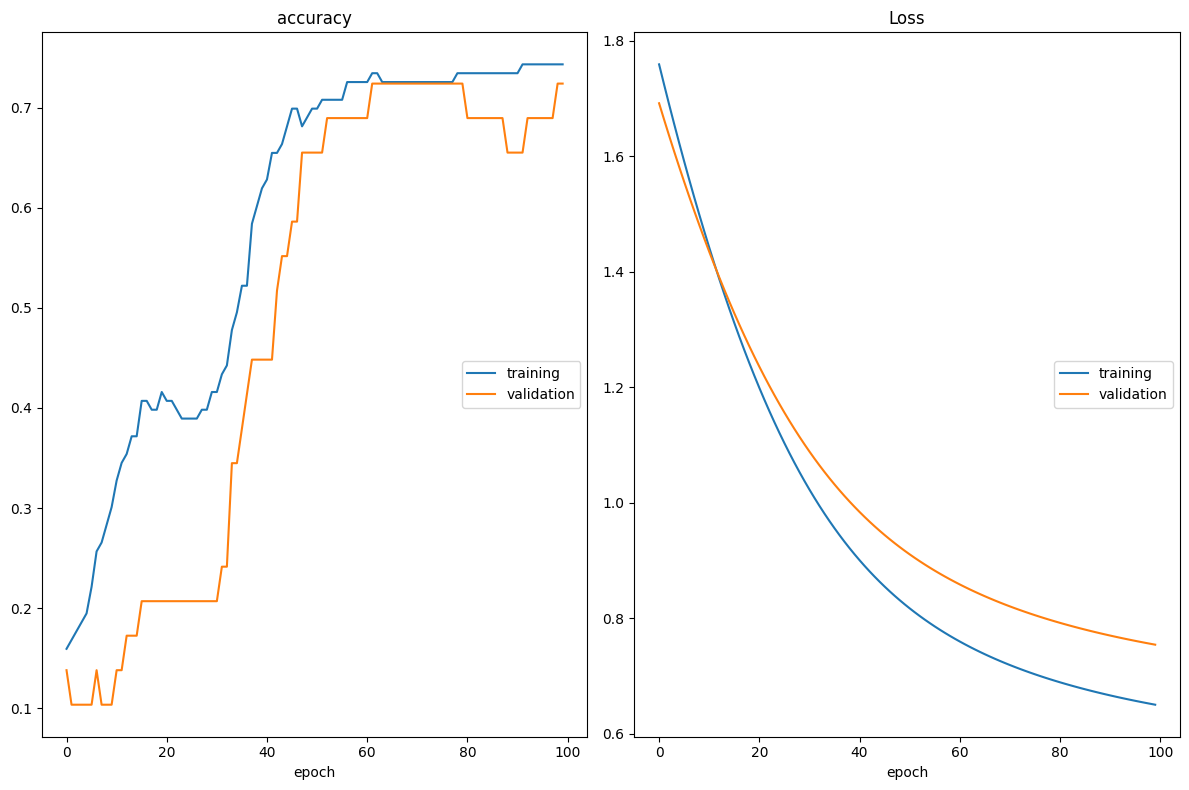

accuracy
	training         	 (min:    0.159, max:    0.743, cur:    0.743)
	validation       	 (min:    0.103, max:    0.724, cur:    0.724)
Loss
	training         	 (min:    0.650, max:    1.759, cur:    0.650)
	validation       	 (min:    0.754, max:    1.692, cur:    0.754)
1/1 - 1s - 914ms/step - accuracy: 0.7434 - loss: 0.6503 - val_accuracy: 0.7241 - val_loss: 0.7543


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping, livelossplot.PlotLossesKeras()],
    verbose=2
)

## Evaluation Metrics

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/tmp/ipykernel_599/2758395613.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


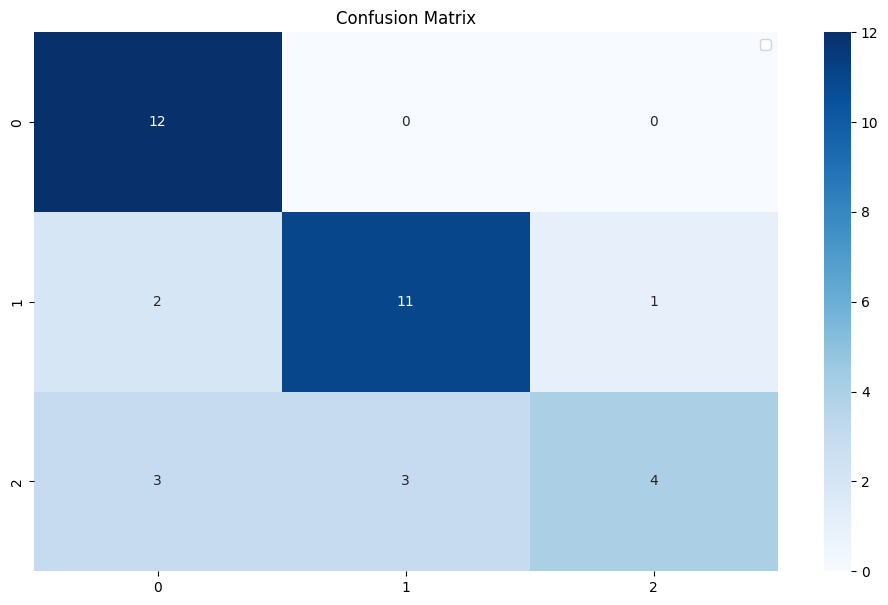

In [59]:
plt.figure(figsize=(12, 7))
sns.heatmap(confusion_matrix(y_test.argmax(axis=1), model.predict(X_test).argmax(axis=1)), annot=True, fmt='d', cmap='Blues')
plt.legend()
plt.title('Confusion Matrix')
plt.show()

In [42]:
print("Classification Report:\n", classification_report(y_test.argmax(axis=1), model.predict(X_test).argmax(axis=1)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.71      1.00      0.83        12
           1       0.80      0.86      0.83        14
           2       1.00      0.40      0.57        10

    accuracy                           0.78        36
   macro avg       0.84      0.75      0.74        36
weighted avg       0.82      0.78      0.76        36



## Saving the Model

In [45]:
model.save('wine_classification_model.keras')
model.save_weights('wine_classification_model.weights.h5')

In [60]:
weights, bias = model.layers[0].get_weights()
print(f"Weights = {weights}, Bias = {bias}")
print(f"Model Weights Shape = {weights.shape}, Bias Shape = {bias.shape}")

Weights = [[ 0.90905344 -0.71999615 -0.16345222]
 [-0.17380755 -0.02013365  0.64314884]], Bias = [ 0.07498148  0.21504942 -0.29003087]
Model Weights Shape = (2, 3), Bias Shape = (3,)


In [62]:
sample_pred = np.argmax(model.predict(X_test[:10], verbose=2), axis=1)
sample_true = y_test[:10].argmax(axis=1)
print(f"Sample Predictions = {sample_pred}")
print(f"Sample True Labels = {sample_true}")

1/1 - 0s - 45ms/step
Sample Predictions = [0 1 0 1 0 0 0 0 2 2]
Sample True Labels = [0 2 0 1 1 0 0 1 1 2]
